### Task 5 - Model Iteration - BERT model 2


Importing all libraries that we will need to exxecute the code and run the model properly: 

In [4]:
import pandas as pd
import re
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
from collections import Counter

In [5]:
import pandas as pd
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    AdamW,
    get_scheduler,
)
from torch.utils.data import Dataset, DataLoader
import torch
from tqdm import tqdm
import nlpaug.augmenter.word as naw
import nltk

# Download required resources
nltk.download("wordnet")
nltk.download("averaged_perceptron_tagger")
nltk.download("omw-1.4")

# Load and clean the dataset
df = pd.read_csv("final_data.csv", encoding="latin1")
df = df.dropna(subset=["Sentence", "Student_Emotion"])
df = df.drop_duplicates(subset=["Sentence", "Student_Emotion"])

# Augment underrepresented emotion classes before balancing
aug = naw.SynonymAug(aug_src="wordnet", aug_min=1, aug_p=0.3)
AUGMENT_FACTOR = 1  # number of augmented samples per original
augmented_rows = []

for label in df["Student_Emotion"].unique():
    subset = df[df["Student_Emotion"] == label]
    if len(subset) < df["Student_Emotion"].value_counts().max():
        for _, row in subset.iterrows():
            for _ in range(AUGMENT_FACTOR):
                try:
                    aug_text = aug.augment(row["Sentence"])
                    augmented_rows.append(
                        {
                            "Sentence": aug_text,
                            "Student_Emotion": row["Student_Emotion"],
                        }
                    )
                except:
                    continue

df_augmented = pd.DataFrame(augmented_rows)
df_combined = pd.concat([df, df_augmented], ignore_index=True)

# Balance the dataset
emotion_counts = df_combined["Student_Emotion"].value_counts()
max_count = emotion_counts.max()
df_balanced = pd.concat(
    [
        resample(
            df_combined[df_combined["Student_Emotion"] == label],
            replace=True,
            n_samples=max_count,
            random_state=42,
        )
        for label in emotion_counts.index
    ]
)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Encode labels
label_encoder = LabelEncoder()
df_balanced["label"] = label_encoder.fit_transform(df_balanced["Student_Emotion"])

# Tokenize sentences
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
encodings = tokenizer(
    list(df_balanced["Sentence"]),
    truncation=True,
    padding=True,
    return_tensors="pt",
)
labels = torch.tensor(df_balanced["label"].values, dtype=torch.long)

# Train-test split
train_idx, test_idx = train_test_split(
    list(range(len(df_balanced))),
    test_size=0.2,
    stratify=df_balanced["label"],
    random_state=42,
)
train_encodings = {k: v[train_idx] for k, v in encodings.items()}
test_encodings = {k: v[test_idx] for k, v in encodings.items()}
train_labels = labels[train_idx]
test_labels = labels[test_idx]


# Custom dataset
class EmotionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item


train_dataset = EmotionDataset(train_encodings, train_labels)
test_dataset = EmotionDataset(test_encodings, test_labels)

# Setup model and training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=len(label_encoder.classes_)
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=5e-5)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
num_training_steps = len(train_loader) * 4
lr_scheduler = get_scheduler(
    "linear", optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
)

# Training loop
model.train()
for epoch in range(4):
    print(f"\nEpoch {epoch+1}/4")
    loop = tqdm(train_loader)
    for batch in loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        loop.set_description(f"Epoch {epoch+1}")
        loop.set_postfix(loss=loss.item())

print("\n✅ Training complete!")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\victo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\victo\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\victo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\victo\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\victo\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptr


Epoch 1/4


Epoch 1: 100%|██████████| 3573/3573 [2:24:16<00:00,  2.42s/it, loss=0.0502]  



Epoch 2/4


Epoch 2:   7%|▋         | 262/3573 [10:45<2:15:54,  2.46s/it, loss=0.017]  


KeyboardInterrupt: 

In [ ]:
import pandas as pd

df = pd.read_csv("final_data.csv", encoding="latin1")
print("Available columns:\n", df.columns.tolist())

Available columns:
 ['text', 'example_very_unclear', 'mapped_emotion', 'Sentence', 'Translation', 'Student_Emotion', 'Pipeline_Emotion', 'Core_Pipeline_Emotion', 'POS_Tags', 'TF_IDF', 'Sentiment_Score', 'Pretrained_Embeddings', 'tokens', 'Custom_Embeddings']


##### Evaluation of the model

In [ ]:
from sklearn.metrics import accuracy_score

model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch in DataLoader(test_dataset, batch_size=16):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        logits = outputs.logits
        predictions.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true_labels.extend(batch["labels"].cpu().numpy())

acc = accuracy_score(true_labels, predictions)
print(f"\n🧪 Test Accuracy: {acc:.4f}")


🧪 Test Accuracy: 0.9630


Further evaluation of the model: 


📊 Model Evaluation Metrics:
Accuracy  : 0.9630
Precision : 0.9629
Recall    : 0.9630
F1-score  : 0.9624

🔍 Classification Report:
              precision    recall  f1-score   support

       anger       0.99      0.99      0.99       390
     disgust       0.98      1.00      0.99       390
        fear       0.98      1.00      0.99       390
   happiness       0.92      0.94      0.93       390
     neutral       0.95      0.85      0.90       390
     sadness       0.97      1.00      0.99       390
    surprise       0.95      0.97      0.96       390

    accuracy                           0.96      2730
   macro avg       0.96      0.96      0.96      2730
weighted avg       0.96      0.96      0.96      2730

🧩 Confusion Matrix:
[[385   5   0   0   0   0   0]
 [  0 390   0   0   0   0   0]
 [  0   0 390   0   0   0   0]
 [  2   0   0 366  15   1   6]
 [  2   0   4  31 331   8  14]
 [  0   0   0   0   0 390   0]
 [  0   2   5   3   1   2 377]]


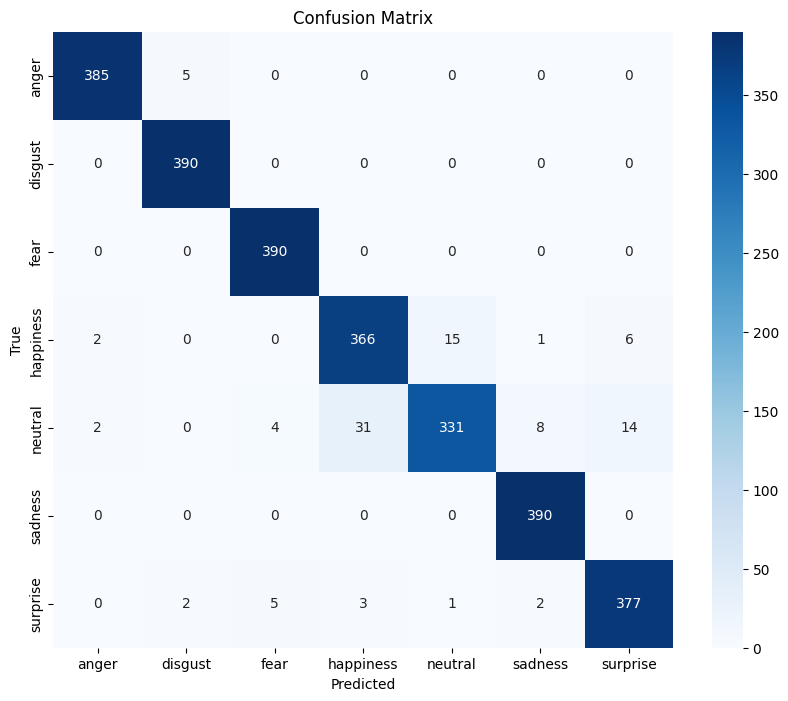

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import numpy as np

model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch in DataLoader(test_dataset, batch_size=16):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        labels = batch["labels"].cpu().numpy()
        predictions.extend(preds)
        true_labels.extend(labels)

#convering to numpy arrays
y_pred = np.array(predictions)
y_true = np.array(true_labels)

#listing all he metrics
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

#printing overall metrics
print("\n📊 Model Evaluation Metrics:")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

#printing full classification report
class_names = label_encoder.classes_
print("\n🔍 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

#display of the confusion matrix
print("🧩 Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Saving the model: 

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model.save_pretrained("emotion_model_BERT_Augmented")
tokenizer.save_pretrained("emotion_model_BERT_tokenizer_Augmented")

('emotion_model_BERT_tokenizer\\tokenizer_config.json',
 'emotion_model_BERT_tokenizer\\special_tokens_map.json',
 'emotion_model_BERT_tokenizer\\vocab.txt',
 'emotion_model_BERT_tokenizer\\added_tokens.json')